In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# Load the data
df = pd.read_csv("../data/cleaned_csv_files/oblig3.csv")

# Print basic information
print("Shape of dataframe:")
print(df.shape)

Shape of dataframe:
(269, 51)


In [2]:
# Separate metadata columns from answer columns
# Row 0 contains answer quality values for answer columns

def is_numeric_score(val):
    """Check if a value can be parsed as a number or looks like a numeric score."""
    if pd.isna(val):
        return False
    try:
        # Try to convert to float
        float(val)
        return True
    except (ValueError, TypeError):
        # Check if it looks like a numeric pattern (including negatives and decimals)
        if isinstance(val, str):
            val_stripped = val.strip()
            # Match patterns like: 1, -1, 1.5, -1.5, 0.5, etc.
            return bool(re.match(r'^-?\d+\.?\d*$', val_stripped))
        return False

# Classify columns
metadata_cols = []
answer_cols = []

for col in df.columns:
    row0_val = df.iloc[0][col]
    if is_numeric_score(row0_val):
        answer_cols.append(col)
    else:
        metadata_cols.append(col)

# Print results
print(f"Number of metadata columns: {len(metadata_cols)}")
print(f"Number of answer columns: {len(answer_cols)}")
print(f"\nMetadata columns ({len(metadata_cols)}):")
print(metadata_cols)
print(f"\nAnswer columns ({len(answer_cols)}):")
print(answer_cols)

# Print table with first 20 answer columns and their row 0 values
print(f"\nFirst 20 answer columns with their row 0 (answer quality) values:")
print("-" * 60)
for col in answer_cols[:20]:
    print(f"{col:40} : {df.iloc[0][col]}")

Number of metadata columns: 6
Number of answer columns: 45

Metadata columns (6):
['kandidatnr', 'created', 'Kjønn', 'Studieprogram', 'Samtykke', 'Answer_time_ms']

Answer columns (45):
['NOR-port', 'XOR-port', 'AND-port', 'Buffer-port', 'Lampe og bryter', 'Port-nivå', 'Mikroarkitektur (datapath/kontroller)', 'Instruksjonssett-arkitektur (ISA)', 'Systemnivå (nettverk/datasenter)', 'KI-modeller som ChatGPT', 'For å balansere hastighet, kapasitet og kostnad', 'For å spare strøm', 'For å gjøre datamaskinen større og mer imponerende', 'Fordi alle minnetyper har samme hastighet', 'Fordi man kan ha flere trinn i pipeline', 'A', 'B', 'AB', 'A´', 'B´', 'Full-adder håndterer mente fra forrige bit-posisjon', 'Full-adder kan håndtere negative tall', 'Full-adder bruker mer strøm', 'Full-adder er raskere enn halv-adder', 'Halv-adder kan bare brukes med 4-bits tall', '0.5 ns', '0.5 us', '0.5 s', '2 ns', '2 s', 'Økt gjennomstrømning', 'Redusert forsinkelse', 'Mindre strømforbruk per instruksjon', 'Mu

In [3]:
# Parse percentage values to probabilities and create student dataframe

def parse_percent_to_prob(x):
    """
    Convert percentage values to probabilities in [0, 1].
    Handles: "75 %", "75%", 75, "0", NaN, etc.
    """
    if pd.isna(x):
        return np.nan
    
    # If already numeric
    if isinstance(x, (int, float)):
        # Assume values > 1 are percentages, values <= 1 are already probabilities
        if x > 1:
            return x / 100.0
        else:
            return float(x)
    
    # If string, clean and parse
    if isinstance(x, str):
        x_clean = x.strip().replace('%', '').replace(' ', '')
        try:
            val = float(x_clean)
            # Assume values > 1 are percentages
            if val > 1:
                return val / 100.0
            else:
                return val
        except ValueError:
            return np.nan
    
    return np.nan

# Create student dataframe (skip row 0 which has answer quality)
df_students = df.iloc[1:].copy()

print(f"Created df_students with shape: {df_students.shape}")
print(f"Converting {len(answer_cols)} answer columns to probabilities...")

# Convert answer columns to probabilities
for col in answer_cols:
    df_students[col] = df_students[col].apply(parse_percent_to_prob)

# Fill missing values with 0
df_students[answer_cols] = df_students[answer_cols].fillna(0)

print("Conversion complete. Filling missing values with 0.")

# Validation: show stats for 5 random rows
print("\n" + "="*80)
print("VALIDATION: Checking 5 random rows")
print("="*80)

sample_rows = df_students.sample(n=min(5, len(df_students)), random_state=42)

for idx in sample_rows.index:
    row_data = df_students.loc[idx, answer_cols]
    min_val = row_data.min()
    max_val = row_data.max()
    
    print(f"\nRow index {idx}:")
    print(f"  Min probability across all answers: {min_val:.3f}")
    print(f"  Max probability across all answers: {max_val:.3f}")
    print(f"  Sample values (first 10 answer columns):")
    for col in answer_cols[:10]:
        print(f"    {col:35} : {df_students.loc[idx, col]:.3f}")
    
print("\n" + "="*80)

Created df_students with shape: (268, 51)
Converting 45 answer columns to probabilities...
Conversion complete. Filling missing values with 0.

VALIDATION: Checking 5 random rows

Row index 116:
  Min probability across all answers: 0.000
  Max probability across all answers: 1.000
  Sample values (first 10 answer columns):
    NOR-port                            : 1.000
    XOR-port                            : 0.000
    AND-port                            : 0.000
    Buffer-port                         : 0.000
    Lampe og bryter                     : 0.000
    Port-nivå                           : 1.000
    Mikroarkitektur (datapath/kontroller) : 0.000
    Instruksjonssett-arkitektur (ISA)   : 0.000
    Systemnivå (nettverk/datasenter)    : 0.000
    KI-modeller som ChatGPT             : 0.000

Row index 214:
  Min probability across all answers: 0.000
  Max probability across all answers: 1.000
  Sample values (first 10 answer columns):
    NOR-port                            : 1.0

In [4]:
# Extract and normalize answer quality values from row 0

# Extract row 0 (answer quality) for answer columns as numeric
q_raw = pd.to_numeric(df.loc[0, answer_cols], errors='coerce')

print(f"Extracted {len(q_raw)} answer quality values from row 0")
print(f"Raw quality stats: min={q_raw.min():.2f}, max={q_raw.max():.2f}, mean={q_raw.mean():.2f}")

# Define global min and max for normalization
global_min = -2
global_max = 3

# Normalize to [-1, 1] using the formula: ((q_raw - min) / (max - min)) * 2 - 1
q_norm = ((q_raw - global_min) / (global_max - global_min)) * 2 - 1

print(f"\nNormalized quality stats: min={q_norm.min():.3f}, max={q_norm.max():.3f}, mean={q_norm.mean():.3f}")

# Create comparison dataframe for first 30 answer columns
comparison_df = pd.DataFrame({
    'q_raw': q_raw[:30],
    'q_norm': q_norm[:30]
})

print("\nFirst 30 answer columns with raw and normalized quality values:")
print(comparison_df.to_string())

# Assert q_norm is within [-1, 1] (allowing for tiny floating point errors)
eps = 1e-10
assert (q_norm >= -1 - eps).all() and (q_norm <= 1 + eps).all(), \
    f"q_norm values outside [-1, 1]: min={q_norm.min()}, max={q_norm.max()}"

print("\n✓ Assertion passed: All normalized values are within [-1, 1]")

Extracted 45 answer quality values from row 0
Raw quality stats: min=-2.00, max=3.00, mean=0.24

Normalized quality stats: min=-1.000, max=1.000, mean=-0.102

First 30 answer columns with raw and normalized quality values:
                                                     q_raw  q_norm
NOR-port                                               3.0     1.0
XOR-port                                               0.5     0.0
AND-port                                               0.0    -0.2
Buffer-port                                            0.0    -0.2
Lampe og bryter                                       -2.0    -1.0
Port-nivå                                              3.0     1.0
Mikroarkitektur (datapath/kontroller)                  1.0     0.2
Instruksjonssett-arkitektur (ISA)                      0.5     0.0
Systemnivå (nettverk/datasenter)                       0.0    -0.2
KI-modeller som ChatGPT                               -2.0    -1.0
For å balansere hastighet, kapasitet og 

In [5]:
# Create question blocks and validate probability sums

# 1) Assert exactly 45 answer columns (9 questions × 5 alternatives)
if len(answer_cols) != 45:
    print(f"ERROR: Expected exactly 45 answer columns (9 questions × 5 alternatives)")
    print(f"       Found: {len(answer_cols)} columns")
    print(f"       Cannot proceed with block creation.")
    raise ValueError(f"Expected 45 answer columns, got {len(answer_cols)}")

print(f"✓ Confirmed: {len(answer_cols)} answer columns (9 questions × 5 alternatives each)")

# 2) Create blocks as consecutive chunks of 5
blocks = [answer_cols[i:i+5] for i in range(0, 45, 5)]

print(f"\nCreated {len(blocks)} question blocks")

# 3) Validate probability sums per block
print("\n" + "="*100)
print("BLOCK VALIDATION: Checking if probabilities sum to ~1.0 for each question")
print("="*100)

block_summaries_data = []

for block_idx, block in enumerate(blocks, start=1):
    # Sum probabilities across the 5 alternatives for each student
    s = df_students[block].sum(axis=1)
    
    # Calculate statistics
    median_s = s.median()
    mean_s = s.mean()
    min_s = s.min()
    max_s = s.max()
    
    # Calculate percentage of students with sum in [0.98, 1.02]
    within_range = ((s >= 0.98) & (s <= 1.02)).sum()
    pct_within_range = (within_range / len(s)) * 100
    
    # Print block information
    print(f"\nBlock {block_idx}:")
    print(f"  Columns: {block}")
    print(f"  Sum statistics:")
    print(f"    Median: {median_s:.4f}")
    print(f"    Mean:   {mean_s:.4f}")
    print(f"    Min:    {min_s:.4f}")
    print(f"    Max:    {max_s:.4f}")
    print(f"  Students with sum in [0.98, 1.02]: {pct_within_range:.1f}%")
    
    # 4) Warning if less than 95% within range
    if pct_within_range < 95:
        print(f"  ⚠️  WARNING: Only {pct_within_range:.1f}% of students have sum in [0.98, 1.02]")
    
    # Store summary data
    block_summaries_data.append({
        'block_index': block_idx,
        'median_sum': median_s,
        'mean_sum': mean_s,
        'min_sum': min_s,
        'max_sum': max_s,
        'pct_within_range': pct_within_range
    })

# Create summary dataframe
block_summaries = pd.DataFrame(block_summaries_data)

print("\n" + "="*100)
print("\nSummary DataFrame:")
print(block_summaries.to_string(index=False))

print(f"\n✓ Block validation complete. Created variables: 'blocks' and 'block_summaries'")

✓ Confirmed: 45 answer columns (9 questions × 5 alternatives each)

Created 9 question blocks

BLOCK VALIDATION: Checking if probabilities sum to ~1.0 for each question

Block 1:
  Columns: ['NOR-port', 'XOR-port', 'AND-port', 'Buffer-port', 'Lampe og bryter']
  Sum statistics:
    Median: 1.0000
    Mean:   1.0756
    Min:    0.7500
    Max:    3.5000
  Students with sum in [0.98, 1.02]: 90.7%
  ⚠️  WARNING: Only 90.7% of students have sum in [0.98, 1.02]

Block 2:
  Columns: ['Port-nivå', 'Mikroarkitektur (datapath/kontroller)', 'Instruksjonssett-arkitektur (ISA)', 'Systemnivå (nettverk/datasenter)', 'KI-modeller som ChatGPT']
  Sum statistics:
    Median: 1.0000
    Mean:   1.0933
    Min:    0.5000
    Max:    3.0000
  Students with sum in [0.98, 1.02]: 86.6%
  ⚠️  WARNING: Only 86.6% of students have sum in [0.98, 1.02]

Block 3:
  Columns: ['For å balansere hastighet, kapasitet og kostnad', 'For å spare strøm', 'For å gjøre datamaskinen større og mer imponerende', 'Fordi alle min

In [6]:
# Compute K scores for each question and overall X score

print("Computing K scores (quality-weighted sum) for each question...")
print("="*80)

# For each block (question), compute K_j = sum(p_col * q_norm[col])
K_columns = []

for block_idx, block in enumerate(blocks, start=1):
    K_col_name = f"K_q{block_idx}"
    K_columns.append(K_col_name)
    
    # Initialize K column with zeros
    df_students[K_col_name] = 0.0
    
    # Sum up: p_col * q_norm[col] for all columns in this block
    for col in block:
        df_students[K_col_name] += df_students[col] * q_norm[col]
    
    print(f"Created {K_col_name}: weighted sum of {len(block)} alternatives")

print(f"\n✓ Created {len(K_columns)} K columns: {K_columns}")

# Compute X as the mean of all K columns
df_students['X'] = df_students[K_columns].mean(axis=1)

print(f"\n✓ Computed X as the mean of all K columns")

# Print summary statistics for X
print("\n" + "="*80)
print("SUMMARY STATISTICS FOR X (overall quality-weighted performance)")
print("="*80)
print(f"Min:    {df_students['X'].min():.4f}")
print(f"Max:    {df_students['X'].max():.4f}")
print(f"Mean:   {df_students['X'].mean():.4f}")
print(f"Std:    {df_students['X'].std():.4f}")
print(f"Median: {df_students['X'].median():.4f}")

# Print 5 random students with their X and first 3 K values
print("\n" + "="*80)
print("SAMPLE: 5 Random Students")
print("="*80)

sample_students = df_students.sample(n=min(5, len(df_students)), random_state=42)

for idx in sample_students.index:
    print(f"\nStudent (row {idx}):")
    print(f"  X (overall):  {df_students.loc[idx, 'X']:.4f}")
    print(f"  K_q1:         {df_students.loc[idx, 'K_q1']:.4f}")
    print(f"  K_q2:         {df_students.loc[idx, 'K_q2']:.4f}")
    print(f"  K_q3:         {df_students.loc[idx, 'K_q3']:.4f}")

print("\n" + "="*80)
print(f"✓ K and X computation complete. Added columns: {K_columns + ['X']}")

Computing K scores (quality-weighted sum) for each question...
Created K_q1: weighted sum of 5 alternatives
Created K_q2: weighted sum of 5 alternatives
Created K_q3: weighted sum of 5 alternatives
Created K_q4: weighted sum of 5 alternatives
Created K_q5: weighted sum of 5 alternatives
Created K_q6: weighted sum of 5 alternatives
Created K_q7: weighted sum of 5 alternatives
Created K_q8: weighted sum of 5 alternatives
Created K_q9: weighted sum of 5 alternatives

✓ Created 9 K columns: ['K_q1', 'K_q2', 'K_q3', 'K_q4', 'K_q5', 'K_q6', 'K_q7', 'K_q8', 'K_q9']

✓ Computed X as the mean of all K columns

SUMMARY STATISTICS FOR X (overall quality-weighted performance)
Min:    -0.3667
Max:    1.0222
Mean:   0.7037
Std:    0.2574
Median: 0.7444

SAMPLE: 5 Random Students

Student (row 116):
  X (overall):  0.9389
  K_q1:         1.0000
  K_q2:         1.0000
  K_q3:         0.7500

Student (row 214):
  X (overall):  0.6389
  K_q1:         1.0000
  K_q2:         1.0000
  K_q3:         1.0000


In [7]:
# Compute confidence scores (C) based on entropy for each question

print("Computing confidence scores (C) for each question...")
print("="*80)

C_columns = []

for block_idx, block in enumerate(blocks, start=1):
    C_col_name = f"C_q{block_idx}"
    C_columns.append(C_col_name)
    
    # Number of alternatives in this block
    m = len(block)
    max_entropy = np.log(m)  # Maximum entropy when all probabilities are equal
    
    # For each student, compute entropy H = -sum(p_i * log(p_i))
    # Then compute confidence C = 1 - H/log(m)
    
    def compute_confidence(row):
        """Compute confidence score from probability distribution."""
        probs = row[block].values
        
        # Compute entropy: H = -sum(p_i * log(p_i))
        # Handle 0*log(0) = 0 case
        entropy = 0
        for p in probs:
            if p > 0:  # Only add term if p > 0 (since 0*log(0) = 0)
                entropy -= p * np.log(p)
        
        # Confidence: C = 1 - H/log(m)
        confidence = 1 - (entropy / max_entropy)
        return confidence
    
    # Apply to all students
    df_students[C_col_name] = df_students.apply(compute_confidence, axis=1)
    
    print(f"Created {C_col_name}: confidence based on entropy (m={m} alternatives)")

print(f"\n✓ Created {len(C_columns)} C columns: {C_columns}")

# Compute Y as 100 * mean of all C columns
df_students['Y'] = 100 * df_students[C_columns].mean(axis=1)

print(f"\n✓ Computed Y as 100 × mean(C) across all questions")

# Compute Y_max as 100 * mean of max probability per block
max_probs = []
for block in blocks:
    max_prob_per_question = df_students[block].max(axis=1)
    max_probs.append(max_prob_per_question)

# Convert to dataframe and compute mean
max_probs_df = pd.DataFrame(max_probs).T
df_students['Y_max'] = 100 * max_probs_df.mean(axis=1)

print(f"✓ Computed Y_max as 100 × mean(max_prob) across all questions")

# Print summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS FOR Y (entropy-based confidence %)")
print("="*80)
print(f"Min:    {df_students['Y'].min():.2f}")
print(f"Max:    {df_students['Y'].max():.2f}")
print(f"Mean:   {df_students['Y'].mean():.2f}")
print(f"Std:    {df_students['Y'].std():.2f}")
print(f"Median: {df_students['Y'].median():.2f}")

print("\n" + "="*80)
print("SUMMARY STATISTICS FOR Y_max (average max probability %)")
print("="*80)
print(f"Min:    {df_students['Y_max'].min():.2f}")
print(f"Max:    {df_students['Y_max'].max():.2f}")
print(f"Mean:   {df_students['Y_max'].mean():.2f}")
print(f"Std:    {df_students['Y_max'].std():.2f}")
print(f"Median: {df_students['Y_max'].median():.2f}")

# Print 5 random students with Y and Y_max
print("\n" + "="*80)
print("SAMPLE: 5 Random Students")
print("="*80)

sample_students = df_students.sample(n=min(5, len(df_students)), random_state=42)

for idx in sample_students.index:
    print(f"\nStudent (row {idx}):")
    print(f"  Y (confidence):       {df_students.loc[idx, 'Y']:.2f}%")
    print(f"  Y_max (max prob):     {df_students.loc[idx, 'Y_max']:.2f}%")

print("\n" + "="*80)
print(f"✓ Confidence computation complete. Added columns: {C_columns + ['Y', 'Y_max']}")

Computing confidence scores (C) for each question...
Created C_q1: confidence based on entropy (m=5 alternatives)
Created C_q2: confidence based on entropy (m=5 alternatives)
Created C_q3: confidence based on entropy (m=5 alternatives)
Created C_q4: confidence based on entropy (m=5 alternatives)
Created C_q5: confidence based on entropy (m=5 alternatives)
Created C_q6: confidence based on entropy (m=5 alternatives)
Created C_q7: confidence based on entropy (m=5 alternatives)
Created C_q8: confidence based on entropy (m=5 alternatives)
Created C_q9: confidence based on entropy (m=5 alternatives)

✓ Created 9 C columns: ['C_q1', 'C_q2', 'C_q3', 'C_q4', 'C_q5', 'C_q6', 'C_q7', 'C_q8', 'C_q9']

✓ Computed Y as 100 × mean(C) across all questions
✓ Computed Y_max as 100 × mean(max_prob) across all questions

SUMMARY STATISTICS FOR Y (entropy-based confidence %)
Min:    -7.67
Max:    100.00
Mean:   85.92
Std:    14.73
Median: 88.35

SUMMARY STATISTICS FOR Y_max (average max probability %)
Min

Computing reliability for bubble sizes (robust)...
Students after cleaning: 264 / 268
Reliability (raw) stats: min=1.14, p2=1.36, p98=100.00, max=100.00, mean=15.25
Bubble size range: [20.0, 200.0]

Creating scatter plot...

✓ Plot saved to: ../results/confidence_quality_bubble.png
  Number of students plotted: 264


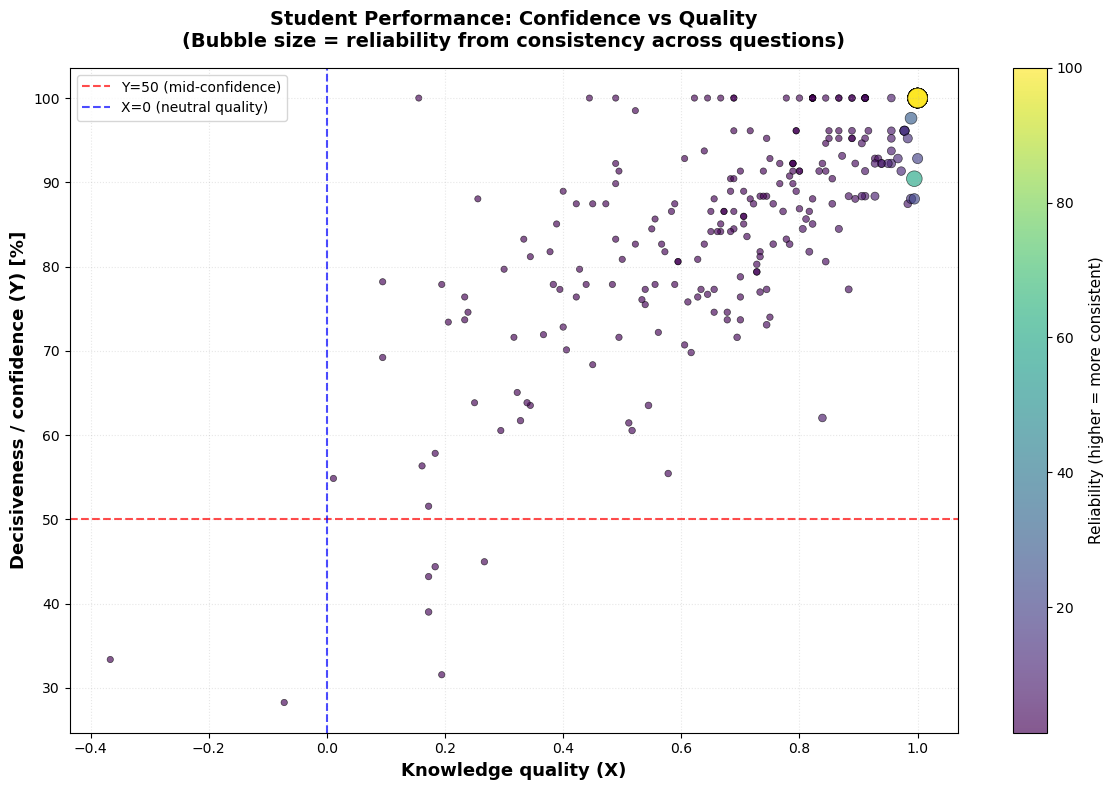


✓ Visualization complete!


In [ ]:
# Bubble plot: Confidence (Y) vs Quality (X) with reliability-based bubble size (robust)

import os
import numpy as np
import matplotlib.pyplot as plt

print("Computing reliability for bubble sizes (robust)...")
print("=" * 80)

# --- 1) Basic validation & filtering (prevents plot mistakes) ---
required_cols = ['X', 'Y'] + K_columns
missing = [c for c in required_cols if c not in df_students.columns]
if missing:
    raise ValueError(f"Missing required columns in df_students: {missing}")

df_plot = df_students[required_cols].copy()

# Drop NaNs / inf
df_plot = df_plot.replace([np.inf, -np.inf], np.nan).dropna(subset=['X', 'Y'])

# Enforce expected ranges (small numeric tolerance allowed)
df_plot = df_plot[(df_plot['X'] >= -1.001) & (df_plot['X'] <= 1.001)]
df_plot = df_plot[(df_plot['Y'] >= -0.001) & (df_plot['Y'] <= 100.001)]

print(f"Students after cleaning: {len(df_plot)} / {len(df_students)}")

# --- 2) Reliability definition (inverse dispersion across K's) ---
k_std = df_plot[K_columns].std(axis=1, ddof=1)

# Avoid explosion: clip std at a small floor (e.g., 0.01) or use percentiles
std_floor = 0.01  # interpretability: "near-perfect consistency" all treated similarly
k_std_clipped = np.maximum(k_std, std_floor)

reliability = 1.0 / k_std_clipped

# Optional: winsorize reliability to avoid one extreme point dominating sizes
r_low, r_high = np.percentile(reliability, [2, 98])
reliability_w = np.clip(reliability, r_low, r_high)

print(
    f"Reliability (raw) stats: min={reliability.min():.2f}, "
    f"p2={r_low:.2f}, p98={r_high:.2f}, max={reliability.max():.2f}, "
    f"mean={reliability.mean():.2f}"
)

# --- 3) Map reliability to bubble sizes robustly ---
size_min, size_max = 20, 200

den = (reliability_w.max() - reliability_w.min())
if den < 1e-12:
    bubble_size = np.full(len(reliability_w), (size_min + size_max) / 2.0)
else:
    bubble_size = size_min + (reliability_w - reliability_w.min()) / den * (size_max - size_min)

print(f"Bubble size range: [{bubble_size.min():.1f}, {bubble_size.max():.1f}]")

# --- 4) Plot ---
print("\nCreating scatter plot...")
fig, ax = plt.subplots(figsize=(12, 8))

sc = ax.scatter(
    df_plot['X'],
    df_plot['Y'],
    s=bubble_size,
    c=reliability_w,              # color = reliability (NOT bubble size)
    cmap='viridis',
    alpha=0.65,
    edgecolors='black',
    linewidth=0.5
)

# Reference lines WHYYYYYYYY wrong legend for X and Y colors??????????
ax.axhline(y=50, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Y=50 (mid-confidence)')
ax.axvline(x=0, color='blue', linestyle='--', linewidth=1.5, alpha=0.7, label='X=0 (neutral quality)')

# Labels
ax.set_xlabel('Knowledge quality (X)', fontsize=13, fontweight='bold')
ax.set_ylabel('Decisiveness / confidence (Y) [%]', fontsize=13, fontweight='bold')
ax.set_title(
    'Student Performance: Confidence vs Quality\n'
    '(Bubble size = reliability from consistency across questions)',
    fontsize=14, fontweight='bold', pad=15
)

# Colorbar now matches what we color
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Reliability (higher = more consistent)', fontsize=11)

# Grid + legend
ax.grid(True, alpha=0.3, linestyle=':')
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()

# --- 5) Save ---
output_dir = "../results"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "confidence_quality_bubble.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight')

print(f"\n✓ Plot saved to: {output_path}")
print(f"  Number of students plotted: {len(df_plot)}")

plt.show()
print("\n" + "=" * 80)
print("✓ Visualization complete!")
